In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load one year of transaction data

In [2]:
months_2025 = [f"{m:02d}" for m in range(6, 13)]
files_2025 = [f"raw-data/CRMLSSold2025{m}.csv" for m in months_2025]
sold_2025 = pd.concat(pd.read_csv(f) for f in files_2025)
sold_2025.shape

/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_20599/2359699924.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  sold_2025 = pd.concat(pd.read_csv(f) for f in files_2025)


(154803, 78)

In [3]:
months_2026 = [f"{m:02d}" for m in range(1, 6)]
files_2026 = [f"raw-data/CRMLSSold2025{m}.csv" for m in months_2026]
sold_2026 = pd.concat(pd.read_csv(f) for f in files_2026)
sold_2026.shape

(105301, 80)

In [4]:
sold_raw = pd.concat([sold_2025, sold_2026])
sold_raw.shape

(260104, 80)

Restrict analysis to single-family residential properties

In [6]:
sold_raw['PropertyType'].unique()
sold_raw['PropertySubType'].unique()

array(['SingleFamilyResidence', nan, 'Condominium', 'Duplex', 'Triplex',
       'Office', 'Apartment', 'Townhouse', 'MixedUse', 'RoomingHouse',
       'ManufacturedOnLand', 'StockCooperative', 'Quadruplex', 'Studio',
       'UnimprovedLand', 'MobileHome', 'BoatSlip', 'Industrial',
       'Warehouse', 'Business', 'Loft', 'Cabin', 'MultiFamily', 'Retail',
       'Agriculture', 'CoOwnership', 'WaterPositionWithLand',
       'OwnYourOwn', 'ManufacturedHome', 'SpecialPurpose', 'HotelMotel',
       'Farm', 'DeededParking', 'Timeshare', 'Ranch'], dtype=object)

In [7]:
sold_residential = sold_raw[sold_raw['PropertyType'] == 'Residential']
sold_sfr = sold_residential[sold_residential['PropertySubType'] == 'SingleFamilyResidence']
sold_sfr.shape

(130210, 80)

Explore distributions of close price, living area, bedrooms, bathrooms, and lot size

In [ ]:
sold_sfr.columns

In [19]:
sold_sfr['ClosePrice'].describe(percentiles=[0, 0.1, 0.25, 0.5, 0.75, 0.9, 1])

count    1.302100e+05
mean     1.320028e+06
std      7.346944e+06
min      0.000000e+00
0%       0.000000e+00
10%      4.450000e+05
25%      6.250000e+05
50%      8.890000e+05
75%      1.415000e+06
90%      2.300000e+06
100%     9.895000e+08
max      9.895000e+08
Name: ClosePrice, dtype: float64

In [ ]:
# DaysOnMarket has negative values
# There is generally a big cutoff from 90th to 100th percentile across columns
sold_sfr[['DaysOnMarket', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeArea', 'LotSizeAcres', 'LotSizeSquareFeet']].describe(percentiles=[0, 0.1, 0.25, 0.5, 0.75, 0.9, 1])

,DaysOnMarket,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeArea,LotSizeAcres,LotSizeSquareFeet
count,130210.000000,130138.000000,130210.000000,130191.000000,1.279780e+05,127968.000000,1.279660e+05
mean,39.158121,2041.409499,3.485439,2.625719,1.956076e+04,13.609383,3.303087e+05
std,50.584724,1045.746758,0.971342,1.141714,6.433867e+05,800.190665,1.628159e+07
min,-265.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
0%,-265.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
10%,4.000000,1103.000000,2.000000,2.000000,3.701000e+03,0.097570,4.248000e+03
25%,8.000000,1381.000000,3.000000,2.000000,5.457000e+03,0.130000,5.663000e+03
50%,20.000000,1810.500000,3.000000,2.000000,7.131500e+03,0.167200,7.281000e+03
75%,51.000000,2429.000000,4.000000,3.000000,1.000000e+04,0.240000,1.045400e+04
90%,98.000000,3204.000000,5.000000,4.000000,1.980000e+04,0.510000,2.221600e+04


Text(0.5, 1.0, 'Distribution of Close Price')

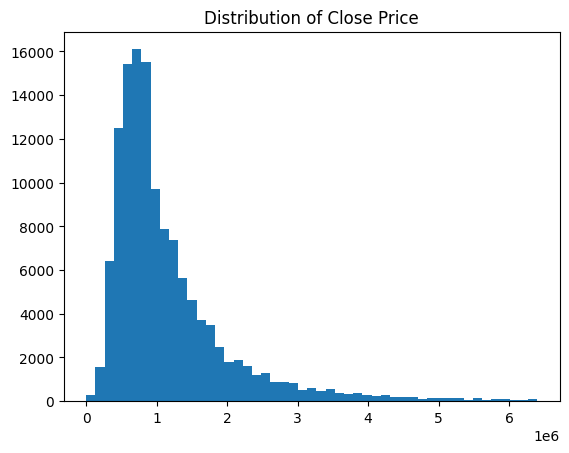

In [65]:
num_bins = 50
bin_cutoffs = np.linspace(sold_sfr['ClosePrice'].quantile(0), sold_sfr['ClosePrice'].quantile(0.99), num_bins)
plt.hist(sold_sfr['ClosePrice'], bins=bin_cutoffs)
plt.title('Distribution of Close Price')

Text(0.5, 1.0, 'Distribution of Days On Market')

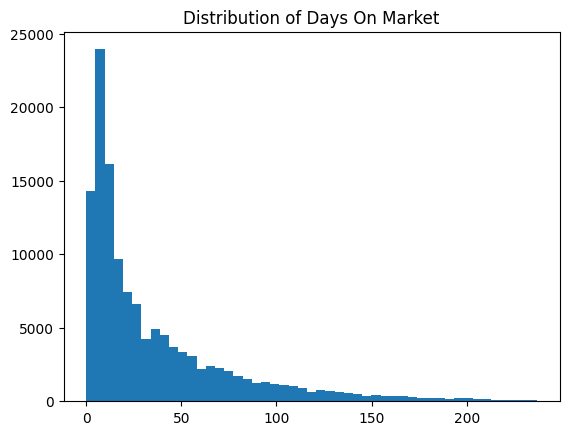

In [64]:
bin_cutoffs = np.linspace(0, sold_sfr['DaysOnMarket'].quantile(0.99), num_bins)
plt.hist(sold_sfr['DaysOnMarket'], bins=bin_cutoffs)
plt.title('Distribution of Days On Market')

Text(0.5, 1.0, 'Distribution of Living Area')

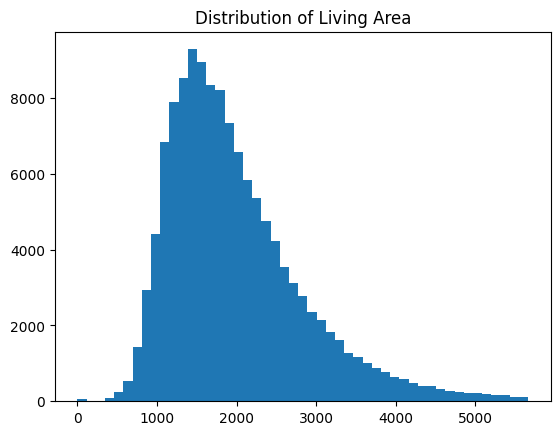

In [63]:
bin_cutoffs = np.linspace(sold_sfr['LivingArea'].quantile(0), sold_sfr['LivingArea'].quantile(0.99), num_bins)
plt.hist(sold_sfr['LivingArea'], bins=bin_cutoffs)
plt.title('Distribution of Living Area')

Text(0.5, 1.0, 'Distribution of Lot Size Area')

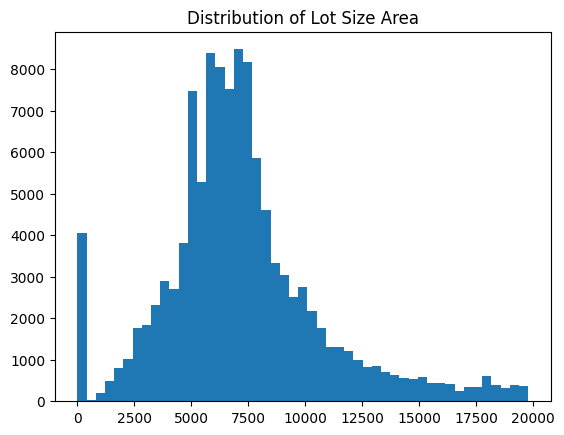

In [62]:
# Over 4000 properties recorded 0 lot size area (not sure about the unit)
bin_cutoffs = np.linspace(sold_sfr['LotSizeArea'].quantile(0), sold_sfr['LotSizeArea'].quantile(0.90), num_bins)
plt.hist(sold_sfr['LotSizeArea'], bins=bin_cutoffs)
plt.title('Distribution of Lot Size Area')

Text(0.5, 1.0, 'Distribution of Lot Size in Acres')

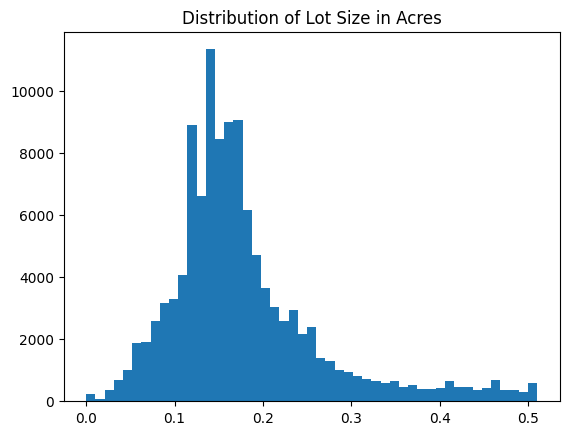

In [61]:
bin_cutoffs = np.linspace(sold_sfr['LotSizeAcres'].quantile(0), sold_sfr['LotSizeAcres'].quantile(0.90), num_bins)
plt.hist(sold_sfr['LotSizeAcres'], bins=bin_cutoffs)
plt.title('Distribution of Lot Size in Acres')

Text(0.5, 1.0, 'Distribution of Lot Size in Square Feet')

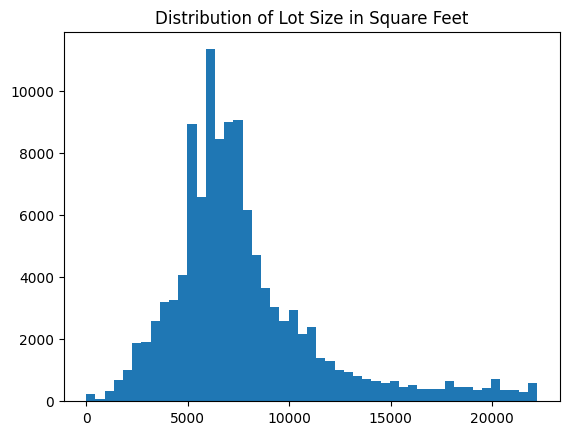

In [60]:
bin_cutoffs = np.linspace(sold_sfr['LotSizeSquareFeet'].quantile(0), sold_sfr['LotSizeSquareFeet'].quantile(0.90), num_bins)
plt.hist(sold_sfr['LotSizeSquareFeet'], bins=bin_cutoffs)
plt.title('Distribution of Lot Size in Square Feet')

Text(0.5, 1.0, 'Distribution of Bedroom Count')

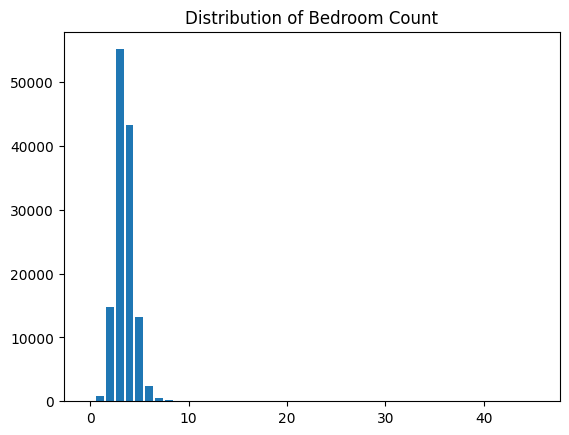

In [59]:
counts = sold_sfr['BedroomsTotal'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Distribution of Bedroom Count')

Text(0.5, 1.0, 'Distribution of Bathroom Count')

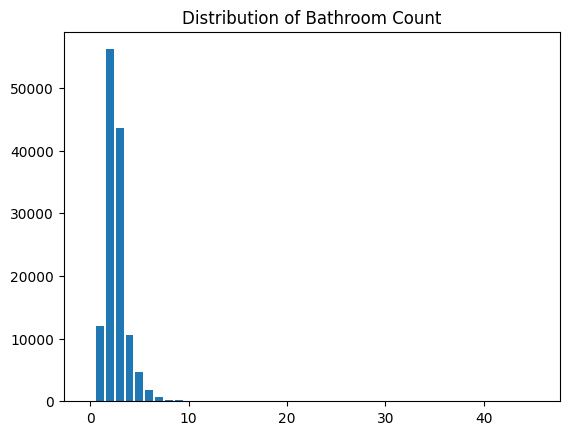

In [66]:
counts = sold_sfr['BathroomsTotalInteger'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Distribution of Bathroom Count')